In [1]:
from ler.gw_source_population import CBCSourceParameterDistribution
import numpy as np
import matplotlib.pyplot as plt

create_new = True
ler = CBCSourceParameterDistribution(
    spin_zero=False,
    spin_precession=True,
    create_new_interpolator=dict(
        a_1=dict(create_new=create_new, resolution=200),
        a_2=dict(create_new=create_new, resolution=200),
        tilt_1=dict(create_new=create_new, resolution=200),
        tilt_2=dict(create_new=create_new, resolution=200, tilt_1_resolution=100),
    ),
)


Initializing CBCSourceRedshiftDistribution class...

luminosity_distance interpolator will be generated at ./interpolator_json/luminosity_distance/luminosity_distance_0.json
differential_comoving_volume interpolator will be generated at ./interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available merger rate density model: merger_rate_density_madau_dickinson_belczynski_ng
merger_rate_density_madau_dickinson_belczynski_ng interpolator will be generated at ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson_belczynski_ng_0.json
merger_rate_density_madau_dickinson_belczynski_ng_detector_frame interpolator will be generated at ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson_belczynski_ng_detector_frame_1.json
merger_rate_density_based_source_redshift interpolator will be generated at ./interpolator_json/merger_rate_density_based_source_redshift/merger_rate_density_based_source_redshift_0.json



## Precessing spins:   

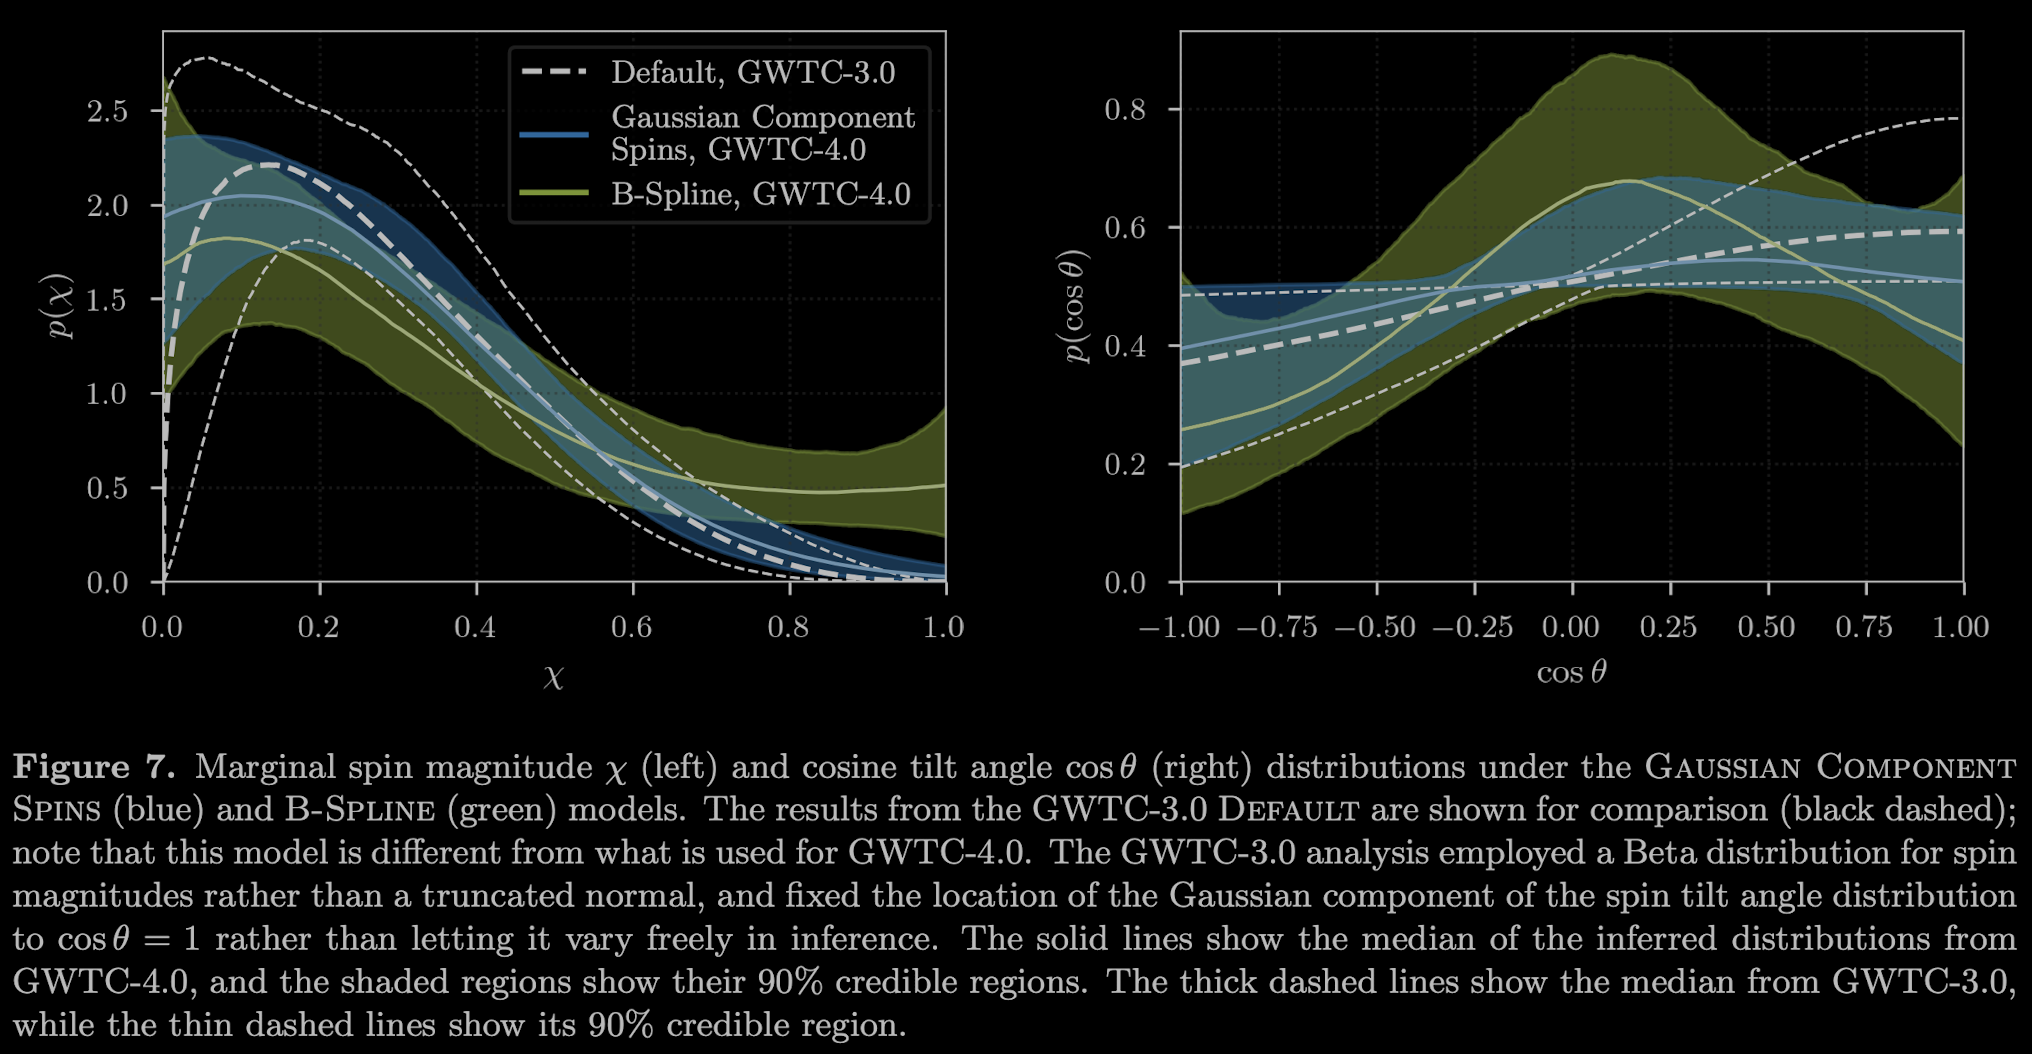

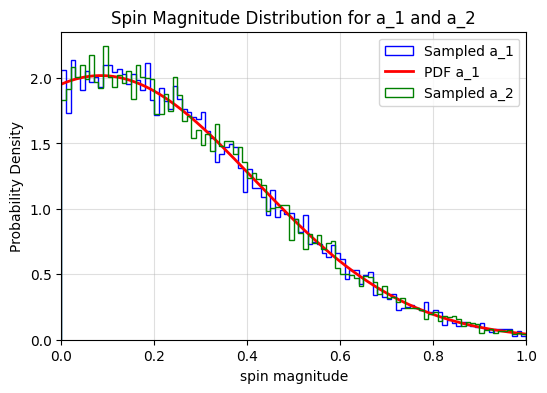

In [2]:
a_1 = ler.a_1.rvs(20000)
a_1_arr = np.linspace(0, 1.0, 200)
a_1_pdf = ler.a_1.pdf(a_1_arr)

a_2 = ler.a_2.rvs(20000)

plt.figure(figsize=(6, 4))
plt.hist(a_1, bins=100, density=True, histtype='step', color='b', label='Sampled a_1')
plt.plot(a_1_arr, a_1_pdf, 'r-', lw=2, label='PDF a_1')
plt.hist(a_2, bins=100, density=True, histtype='step', color='g', label='Sampled a_2')
plt.xlabel("spin magnitude")
plt.xlim(0, 1.0)
plt.ylabel("Probability Density")
plt.title("Spin Magnitude Distribution for a_1 and a_2")
plt.grid(alpha=0.4)
plt.legend()
plt.show()

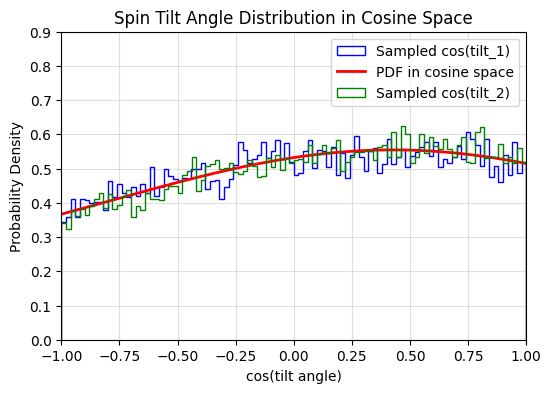

In [3]:
# tilt angle in cosine space
# take care of the jacobian
tilt_1 = ler.tilt_1.rvs(20000)
tilt_1_arr = np.linspace(0, np.pi, 200)
tilt_1_pdf = ler.tilt_1.pdf(tilt_1_arr)

cos_tilt_1 = np.cos(tilt_1)
cos_tilt_1_arr = np.linspace(-0.999, 0.999, 200)  # avoid singularities at ±1
theta_from_cos = np.arccos(cos_tilt_1_arr)

# Jacobian: p(cosθ) = p(θ) * |dθ/d(cosθ)| = p(θ) / sin(θ)
cos_tilt_1_pdf = ler.tilt_1.pdf(theta_from_cos) / np.sqrt(1.0 - cos_tilt_1_arr**2)

tilt_2 = ler.tilt_2.rvs(20000, tilt_1)
cos_tilt_2 = np.cos(tilt_2)



plt.figure(figsize=(6, 4))
plt.hist(cos_tilt_1, bins=100, density=True, histtype='step', color='b', label='Sampled cos(tilt_1)')
plt.plot(cos_tilt_1_arr, cos_tilt_1_pdf, 'r-', lw=2, label='PDF in cosine space')
plt.hist(cos_tilt_2, bins=100, density=True, histtype='step', color='g', label='Sampled cos(tilt_2)')
plt.xlabel("cos(tilt angle)")
plt.xlim(-1, 1)
plt.ylim(0, 0.9)
plt.ylabel("Probability Density")
plt.title("Spin Tilt Angle Distribution in Cosine Space")
plt.grid(alpha=0.4)
plt.legend()
plt.show()

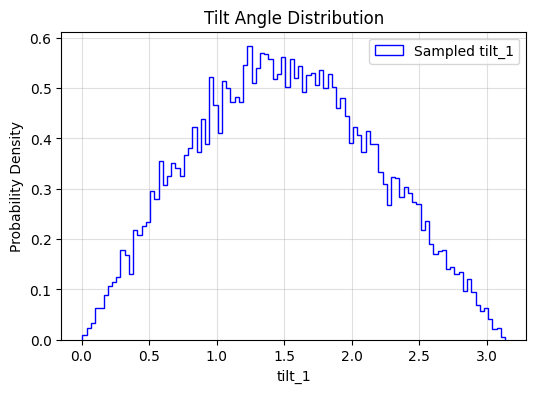

In [4]:
# plot tilt_1
tilt_1 = ler.tilt_1.rvs(20000)
plt.figure(figsize=(6, 4))
plt.hist(tilt_1, bins=100, density=True, histtype='step', color='b', label='Sampled tilt_1')
plt.xlabel("tilt_1")
plt.ylabel("Probability Density")
plt.title("Tilt Angle Distribution")
plt.grid(alpha=0.4)
plt.legend()
plt.show()

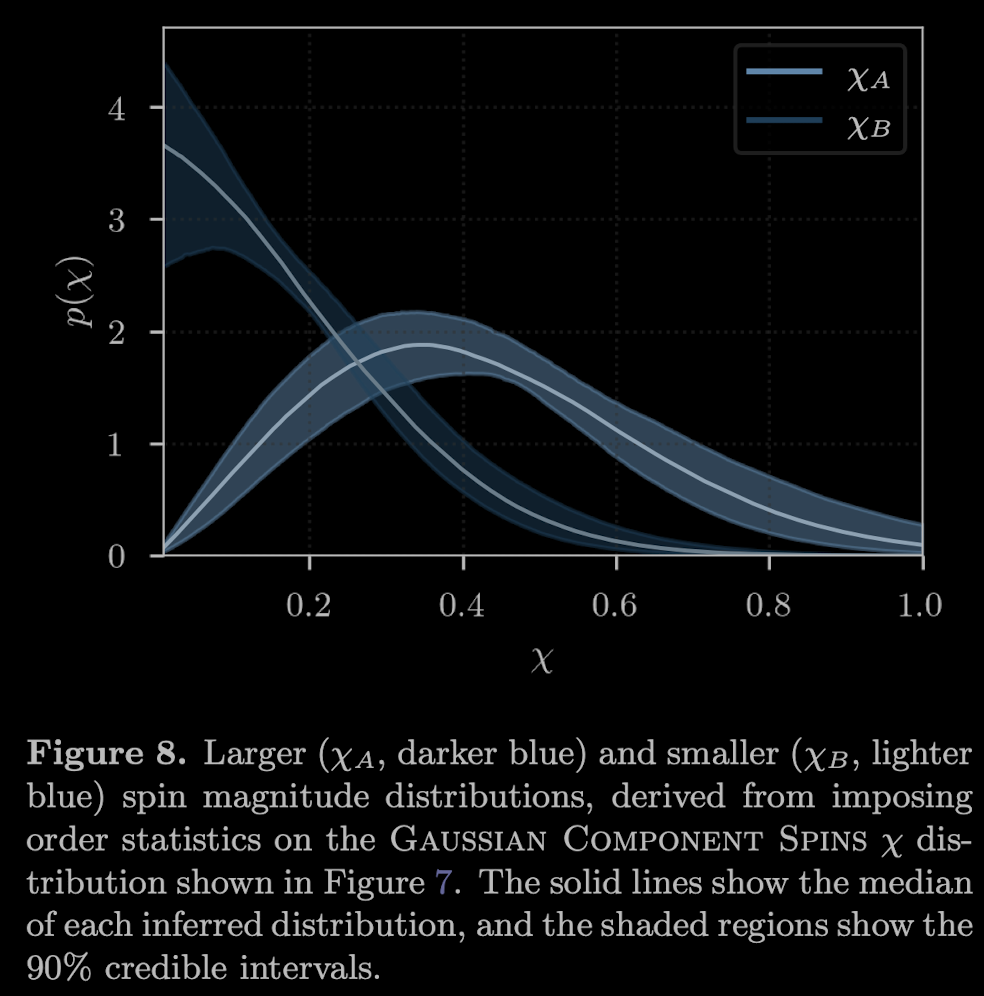

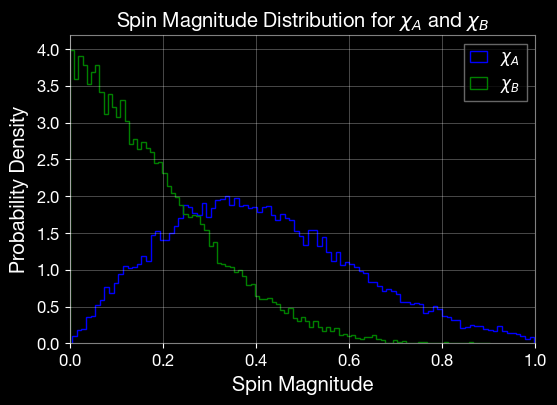

In [6]:
size = a_1.shape[0]
chi_A = np.zeros(size)
chi_B = np.zeros(size)
for i in range(size):
    chi_A[i] = np.max([a_1[i], a_2[i]])
    chi_B[i] = np.min([a_1[i], a_2[i]])

# plot chi_A and chi_B
plt.figure(figsize=(6, 4))
plt.hist(chi_A, bins=100, density=True, histtype='step', color='b', label='$\\chi_A$')
plt.hist(chi_B, bins=100, density=True, histtype='step', color='g', label='$\\chi_B$')
plt.xlabel("Spin Magnitude")
plt.xlim(0, 1.0)
plt.ylabel("Probability Density")
plt.title("Spin Magnitude Distribution for $\\chi_A$ and $\\chi_B$")
plt.grid(alpha=0.4)
plt.legend()
plt.show()

## No spins:   

In [1]:
from ler.gw_source_population import CBCSourceParameterDistribution
import numpy as np
import matplotlib.pyplot as plt

create_new = True
ler = CBCSourceParameterDistribution(
    spin_zero=True,
    spin_precession=False,
    create_new_interpolator=dict(
        a_1=dict(create_new=create_new, resolution=200),
        a_2=dict(create_new=create_new, resolution=200),
        tilt_1=dict(create_new=create_new, resolution=200),
        tilt_2=dict(create_new=create_new, resolution=200, tilt_1_resolution=100),
    ),
)


Initializing CBCSourceRedshiftDistribution class...

luminosity_distance interpolator will be loaded from ./interpolator_json/luminosity_distance/luminosity_distance_0.json
differential_comoving_volume interpolator will be loaded from ./interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available merger rate density model: merger_rate_density_madau_dickinson_belczynski_ng
merger_rate_density_madau_dickinson_belczynski_ng interpolator will be loaded from ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson_belczynski_ng_9.json
merger_rate_density_madau_dickinson_belczynski_ng_detector_frame interpolator will be loaded from ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson_belczynski_ng_detector_frame_5.json
source_redshift interpolator will be loaded from ./interpolator_json/source_redshift/source_redshift_2.json

Initializing CBCSourceParameterDistribution class...

using ler available zs functi

In [2]:
ler.a_1?

Type:        property
String form: <property object at 0x155bf5710>
Docstring:  
Class object (of FunctionConditioning) for spin1 magnitude, with rvs/sampler as callback. Can also be a user defined callable sampler. 

The class object contains the following attribute methods: 

- `rvs`: returns random samples from the spin1 magnitude distribution 

- `pdf`: returns the probability density function of the spin1 magnitude distribution 

- `function`: returns the spin1 magnitude distribution function.

- `None` : if spin_zero=True.

Returns
-------
a_1 : ``numpy.ndarray``
    Array of spin magnitude values for the primary body.

## Aligned spins:   

In [1]:
from ler.gw_source_population import CBCSourceParameterDistribution
import numpy as np
import matplotlib.pyplot as plt

create_new = True
ler = CBCSourceParameterDistribution(
    spin_zero=False,
    spin_precession=False,
    create_new_interpolator=dict(
        a_1=dict(create_new=create_new, resolution=200),
        a_2=dict(create_new=create_new, resolution=200),
        tilt_1=dict(create_new=create_new, resolution=200),
        tilt_2=dict(create_new=create_new, resolution=200, tilt_1_resolution=100),
    ),
)


Initializing CBCSourceRedshiftDistribution class...

luminosity_distance interpolator will be loaded from ./interpolator_json/luminosity_distance/luminosity_distance_0.json
differential_comoving_volume interpolator will be loaded from ./interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available merger rate density model: merger_rate_density_madau_dickinson_belczynski_ng
merger_rate_density_madau_dickinson_belczynski_ng interpolator will be loaded from ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson_belczynski_ng_9.json
merger_rate_density_madau_dickinson_belczynski_ng_detector_frame interpolator will be loaded from ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson_belczynski_ng_detector_frame_5.json
source_redshift interpolator will be loaded from ./interpolator_json/source_redshift/source_redshift_2.json

Initializing CBCSourceParameterDistribution class...

using ler available zs functi

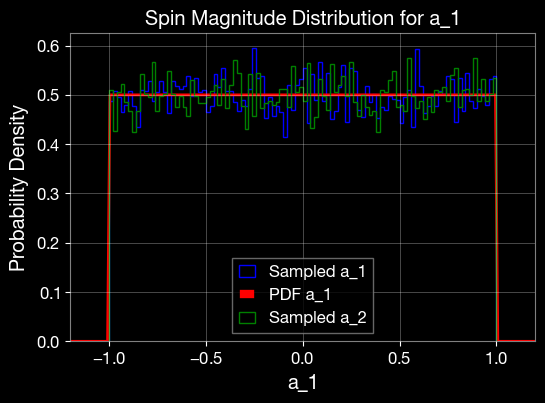

In [2]:
a_1 = ler.a_1.rvs(20000)
a_1_arr = np.linspace(-1.2, 1.2, 200)
a_1_pdf = ler.a_1.pdf(a_1_arr)

a_2 = ler.a_2.rvs(20000)

plt.figure(figsize=(6, 4))
plt.hist(a_1, bins=100, density=True, histtype='step', color='b', label='Sampled a_1')
plt.plot(a_1_arr, a_1_pdf, 'r-', lw=2, label='PDF a_1')
plt.xlabel("a_1")
plt.hist(a_2, bins=100, density=True, histtype='step', color='g', label='Sampled a_2')
plt.xlim(-1.2, 1.2)
plt.ylabel("Probability Density")
plt.title("Spin Magnitude Distribution for a_1")
plt.grid(alpha=0.4)
plt.legend()
plt.show()